In [1]:
import itertools
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import pickle


import STX3KO_analyses as stx
from STX3KO_analyses import utilities_ES as u

ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice
sparse_mice = stx.ymaze_sess_deets.sparse_mice

plt.rcParams['pdf.fonttype']=42
plt.rcParams['font.family'] ='sans-serif'
plt.rcParams['font.serif'] = 'Arial'


%matplotlib inline

%load_ext autoreload
%autoreload 2

In [72]:
import pickle 
with open('/home/mplitt/shuffle_pkls/sparse_place_field_spatial_shuffle_F_dff.pkl','rb') as file:
    shuff_results = pickle.load(file)

In [40]:
# print(shuff_results[sparse_mice[0]]['channel_0'][0]['nov']['field_widths'].shape)
# print(shuff_results[sparse_mice[0]]['channel_0'][0]['nov']['rising_edges'])

rising_edges = shuff_results[sparse_mice[0]]['channel_0'][0]['nov']['rising_edges']
falling_edges = shuff_results[sparse_mice[0]]['channel_0'][0]['nov']['falling_edges']
width = falling_edges[:,1]-rising_edges[:,1]
mask = (width>1) * (width<25)

rising_edges_masked = rising_edges[mask,:]


In [41]:
rising_edges_masked

array([[  0,   3],
       [  0,  16],
       [  3,  20],
       [  4,   0],
       [  7,   1],
       [  7,   5],
       [  7,  28],
       [ 10,   2],
       [ 11,  14],
       [ 11,  28],
       [ 12,  13],
       [ 13,  21],
       [ 14,   4],
       [ 16,   2],
       [ 18,   0],
       [ 20,  28],
       [ 21,   2],
       [ 22,  16],
       [ 23,   9],
       [ 25,  14],
       [ 26,  16],
       [ 27,  12],
       [ 29,  25],
       [ 30,   1],
       [ 33,  23],
       [ 34,   2],
       [ 36,  16],
       [ 38,   0],
       [ 39,   0],
       [ 39,  15],
       [ 42,  26],
       [ 44,  26],
       [ 46,   0],
       [ 47,   4],
       [ 47,  20],
       [ 48,   3],
       [ 50,  22],
       [ 51,  25],
       [ 52,   0],
       [ 53,   0],
       [ 57,  27],
       [ 58,  10],
       [ 68,   3],
       [ 68,  10],
       [ 70,  15],
       [ 71,  22],
       [ 72,   6],
       [ 74,  14],
       [ 77,  17],
       [ 78,   2],
       [ 80,  12],
       [ 81,  17],
       [ 82,

In [90]:
df = {'chan': [], 'mouse': [], 'day': [], 'nov': [], 'n_fields': []}
for mouse in sparse_mice:
    for day in range(6):
        if (mouse == 'SparseKO_09') and (day==2):
            continue

        for nov in ('fam','nov'):
            for chan in ('channel_0', 'channel_1'):
                # n_fields = shuff_results[mouse][chan][day][nov]['num_fields']

                rising_edges = shuff_results[mouse][chan][day][nov]['rising_edges']
                falling_edges = shuff_results[mouse][chan][day][nov]['falling_edges']

                width = falling_edges[:,1]-rising_edges[:,1]
                mask = (width>1) * (width<25)

                n_fields = np.bincount(rising_edges[mask,0])
                

                # widths = shuff_resu
        
                n_fields = n_fields[n_fields>0]

                for n in n_fields:
                    df['mouse'].append(mouse)
                    df['day'].append(day)
                    df['nov'].append(nov)
                    df['chan'].append(chan)
                    df['n_fields'].append(n)

df = pd.DataFrame.from_dict(df)
        

In [25]:

df = {'chan': [], 'mouse': [], 'day': [], 'nov': [], 'n_fields': []}
for mouse in sparse_mice:
    for day in range(5,6):
        sess = u.load_single_day(mouse, day, pkl_basedir='/home/mplitt/YMazeSessPkls')
        if (mouse == 'SparseKO_09') and (day==2):
            continue

        for nov in ('fam','nov'):
            for chan in ('channel_0', 'channel_1'):

                sig_bins = sess.field_perm_masks['sig_bins'][chan][nov]
                # print(sig_bins)
                _sig_bins = np.zeros((sig_bins.shape[0]+1, sig_bins.shape[1]))==1

                _sig_bins[1:,:] = sig_bins

                left_edges = 1*(_sig_bins[1:,:]>_sig_bins[:-1,:])
                n_fields = left_edges.sum(axis=0)
                n_fields = n_fields[n_fields>0]

                for n in n_fields:
                    df['mouse'].append(mouse)
                    df['day'].append(day)
                    df['nov'].append(nov)
                    df['chan'].append(chan)
                    df['n_fields'].append(n)

df = pd.DataFrame.from_dict(df)
        

{'date': '21_11_2024', 'scene': 'YMaze_LNovel', 'session': 2, 'scan': 8, 'novel_arm': -1, 'exp_day': 6}
{'date': '31_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': 1, 'exp_day': 6}
{'date': '31_05_2025', 'scene': 'YMaze_LNovel', 'session': 2, 'scan': 6, 'novel_arm': -1, 'exp_day': 6}


KeyboardInterrupt: 

In [ ]:
sess.mouse

'SparseKO_09'

: 

(0.0, 1.1)

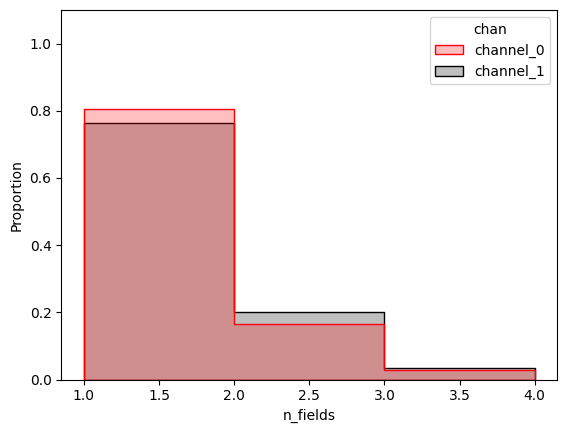

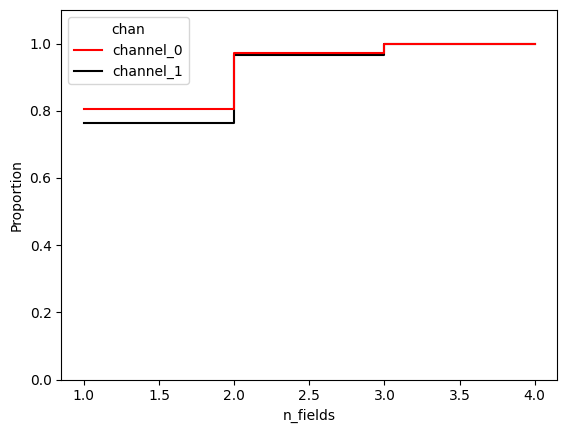

In [45]:
fig,ax = plt.subplots()
sns.histplot(data=df, x='n_fields', hue='chan', cumulative=False, hue_order=('channel_0', 'channel_1'), palette=['red', 'black'],
            binwidth=1, fill=True, element = 'step', stat='proportion', common_norm=False, ax=ax)
ax.set_ylim([0,1.1])

fig,ax = plt.subplots()
sns.histplot(data=df, x='n_fields', hue='chan', cumulative=True, hue_order=('channel_0', 'channel_1'), palette=['red', 'black'],
            binwidth=1, fill=False, element = 'step', stat='proportion', common_norm=False, ax=ax)
ax.set_ylim([0,1.1])



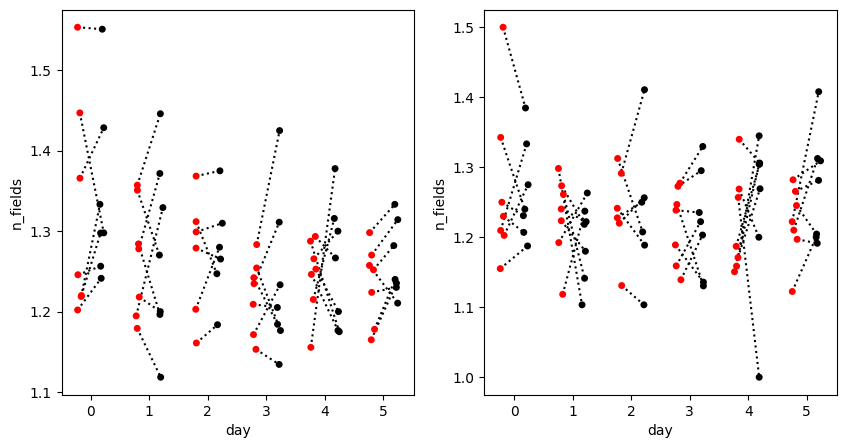

In [99]:
df_mu = df.groupby(['mouse','day','chan','nov'])['n_fields'].mean().reset_index()
df_mu.head()
fig,ax = plt.subplots(1,2, figsize=[10,5])
for i, nov in enumerate(('fam','nov')):
    ax[i] = sns.stripplot(data=df_mu.loc[df_mu['nov']==nov,:],
                x='day',
                y='n_fields',
                hue='chan', 
                hue_order=('channel_0', 'channel_1'), 
                palette=['red', 'black'],
                dodge=True,
                ax=ax[i],
                legend=False)


    for d in range(0,12,2):
        for (x0, y0), (x1, y1) in zip(ax[i].collections[d].get_offsets(), ax[i].collections[d+1].get_offsets()):
            ax[i].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)



In [ ]:
df_mu = df.groupby(['mouse','day','chan','nov'])['n_fields'].mean().reset_index()
df_mu.head()
fig,ax = plt.subplots()
ax = sns.stripplot(data=df_mu.loc[df_mu['nov']=='nov',:],
            x='day',
            y='n_fields',
            hue='chan', 
            hue_order=('channel_0', 'channel_1'), 
            palette=['red', 'black'],
            dodge=True,
            ax=ax,
            legend=False)


for d in range(0,12,2):
    for (x0, y0), (x1, y1) in zip(ax.collections[d].get_offsets(), ax.collections[d+1].get_offsets()):
        ax.plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)


In [95]:
ax

<Axes: xlabel='day', ylabel='n_fields'>

In [62]:
rank_sum_shuffle = []
rng = np.random.default_rng()


for perm in range(1000):
    df_shuff = df.copy()

    stat = 0
    for mouse in sparse_mice:
        
        mask = df_shuff['mouse']==mouse
        sub_df = df_shuff.loc[mask,:].copy()
        chans = sub_df.loc[mask,'chan'].copy()
        sub_df.loc[mask,'chan'] = rng.permutation(chans)

        s, _ = sp.stats.mannwhitneyu(sub_df.loc[sub_df['chan']=='channel_0','n_fields'],sub_df.loc[sub_df['chan']=='channel_1','n_fields'])
        stat += s
    rank_sum_shuffle.append(stat/sub_df.shape[0])
    if perm%100==0:
        print(perm)





0
100
200
300
400
500
600
700
800
900


In [47]:
print(rank_sum_shuffle)

[np.float64(0.409300302087617), np.float64(0.8375282049627726), np.float64(-0.6148206876503928), np.float64(0.23684882824559833), np.float64(-0.9686435391538447), np.float64(1.190698380576999), np.float64(0.6621034298476157), np.float64(0.3709374637098088), np.float64(-0.3213340961286731), np.float64(-0.28529188313477766), np.float64(-1.3638025303082433), np.float64(0.5794311505457228), np.float64(0.5227208677263542), np.float64(0.582404451818861), np.float64(-0.44236921380837413), np.float64(-0.38036500433195447), np.float64(1.074957189554349), np.float64(-0.4784114268022695), np.float64(0.3833383056050927), np.float64(1.1913510564662246), np.float64(0.21320745714698686), np.float64(-1.464169578162471), np.float64(-0.2616505120361662), np.float64(0.1594704756007565), np.float64(-0.5351217096216381), np.float64(0.45360974301170165), np.float64(-0.6662370438127103), np.float64(-0.7518826243877414), np.float64(0.4607166582499345), np.float64(1.0726365641704363), np.float64(0.231554901588

In [69]:
true_rank_sum = 0
for mouse in sparse_mice:
    mask = df['mouse']==mouse
    sub_df = df.loc[mask,:].copy()

    s, _ = sp.stats.mannwhitneyu(sub_df.loc[sub_df['chan']=='channel_0','n_fields'],sub_df.loc[sub_df['chan']=='channel_1','n_fields'])
    true_rank_sum += (s/sub_df.shape[0])

In [65]:
true_rank_sum, p = sp.stats.mannwhitneyu(df.loc[df['chan']=='channel_0','n_fields'],df.loc[df['chan']=='channel_1','n_fields'])
p = (rank_sum_shuffle>true_rank_sum).sum().astype(float)/len(rank_sum_shuffle)
print(f'p-value = {p}')

p-value = 0.0


In [71]:
print(np.mean(df.loc[df['chan']=='channel_0','n_fields']), np.mean(df.loc[df['chan']=='channel_1','n_fields']))

1.2242798353909465 1.2707838479809976


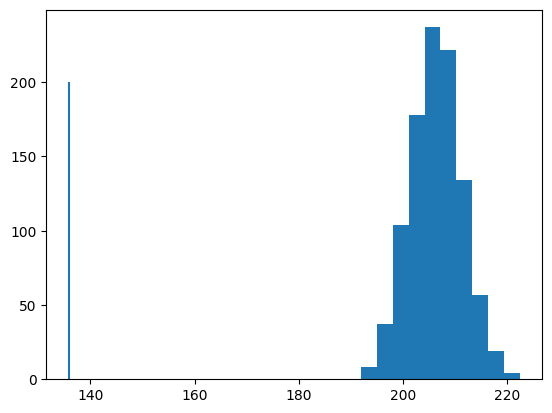

In [70]:
fig, ax = plt.subplots()
ax.hist(rank_sum_shuffle)
ax.vlines(true_rank_sum,0,200)

In [ ]:
df = {'chan': [], 'mouse': [], 'day': [], 'nov': [], 'width': []}
for mouse in sparse_mice:
    for day in range(6):
        
        if (mouse == 'SparseKO_09') and (day==2):
            continue

        for nov in ('fam','nov'):
            for chan in ('channel_0', 'channel_1'):
                widths = shuff_results[mouse][chan][day][nov]['field_widths']

                for w in widths:
                   
                    df['mouse'].append(mouse)
                    df['day'].append(day)
                    df['nov'].append(nov)
                    df['chan'].append(chan)
                    df['width'].append(w)

                    # df['speed'].append(avg_speed[ledge[0]:ledge[0]+redge+1][0]*10*sess.scan_info['frame_rate'])
#                             # print(avg_speed[ledge[0]:ledge[0]+redge+1])
df = pd.DataFrame.from_dict(df)

(0.0, 1.1)

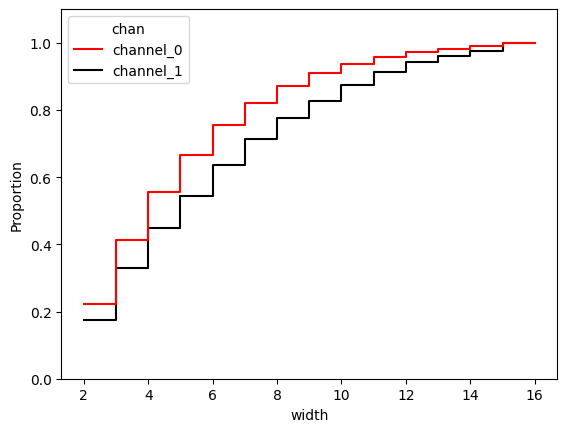

In [106]:
fig,ax = plt.subplots()
sns.histplot(data=df, x='width', hue='chan', cumulative=True, hue_order=('channel_0', 'channel_1'), palette=['red', 'black'],
            binwidth=1, fill=False, element = 'step', stat='proportion', common_norm=False, ax=ax)
ax.set_ylim([0,1.1])

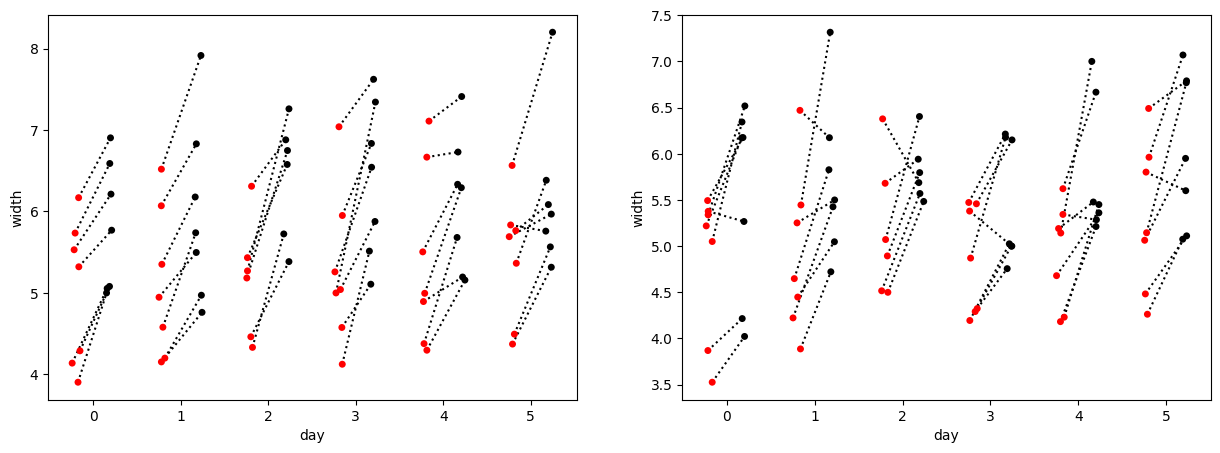

In [107]:
df_mu = df.groupby(['mouse','day','chan','nov'])['width'].mean().reset_index()
df_mu.head()
fig,ax = plt.subplots(1,2, figsize=[15,5])
for i, nov in enumerate(('fam','nov')):
    ax[i] = sns.stripplot(data=df_mu.loc[df_mu['nov']==nov,:],
                x='day',
                y='width',
                hue='chan', 
                hue_order=('channel_0', 'channel_1'), 
                palette=['red', 'black'],
                dodge=.2,
                ax=ax[i],
                legend=False)


    for d in range(0,12,2):
        for (x0, y0), (x1, y1) in zip(ax[i].collections[d].get_offsets(), ax[i].collections[d+1].get_offsets()):
            ax[i].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

In [ ]:
rank_sum_shuffle = []
rng = np.random.default_rng()


for perm in range(1000):
    df_shuff = df.copy()

    stat = 0
    for mouse in sparse_mice:
        mask = df_shuff['mouse']==mouse
        chans = df_shuff.loc[mask,'chan'].copy()
        df_shuff.loc[mask,'chan'] = rng.permutation(chans)

        s, _ = sp.stats.mannwhitneyu(df_shuff.loc[df_shuff['chan']=='channel_0','width'],df_shuff.loc[df_shuff['chan']=='channel_1','width'])
    rank_sum_shuffle.append(s/)
    if perm%100==0:
        print(perm)




0
100
200
300
400
500
600
700
800
900


In [58]:
true_rank_sum, p = sp.stats.ranksums(df.loc[df['chan']=='channel_0','width'],df.loc[df['chan']=='channel_1','width'])
p = (rank_sum_shuffle<true_rank_sum).sum().astype(float)/len(rank_sum_shuffle)
print(f'p-value = {p}')

p-value = 0.0


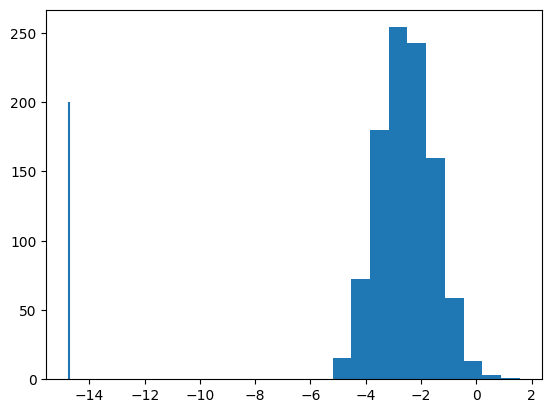

In [59]:
fig, ax = plt.subplots()
ax.hist(rank_sum_shuffle)
ax.vlines(true_rank_sum,0,200)

In [ ]:
df = {'chan': [], 'mouse': [], 'day': [], 'nov': [], 'width': [], 'speed':[]}
for mouse in sparse_mice:
    for day in range(6):
        print(mouse, day)
        sess = u.load_single_day(mouse, day, pkl_basedir='/home/mplitt/YMazeSessPkls')
        # print(sess.vr_data_chan0.columns)
        
        
        if (mouse == 'SparseKO_09') and (day==2):
            continue

        for nov in ('fam','nov'):
            for chan in ('channel_0', 'channel_1'):
                

                sig_bins = sess.field_perm_masks['sig_bins'][chan][nov]

                if nov == 'fam':
                    trial_mask = sess.trial_info['LR']!=sess.novel_arm
                else:
                    trial_mask = sess.trial_info['LR']==sess.novel_arm


                try:
                    avg_speed = np.nanmean(sess.trial_matrices['channel_0_speed'][trial_mask,:],axis=0)
                except:
                    avg_speed = np.nanmean(sess.trial_matrices['speed'][trial_mask,:],axis=0)
                # print(avg_speed.shape)

                left_edges = np.argwhere(sig_bins[1:,:]>sig_bins[:-1,:]) # will exclude beginning of track
                for ledge in left_edges:
                    # print(ledge)
                    if ledge[0]<29:
                        rem_trial = sig_bins[ledge[0]:,ledge[1]]
                        falling_edges = rem_trial[1:]<rem_trial[:-1]
                        if falling_edges.sum()>0: # excludes end of track
                            redge = np.argwhere(falling_edges)[0][0]
                            
                            df['mouse'].append(mouse)
                            df['day'].append(day)
                            df['nov'].append(nov)
                            df['chan'].append(chan)
                            df['width'].append(10*redge)

                            df['speed'].append(avg_speed[ledge[0]:ledge[0]+redge+1][0]*10*sess.scan_info['frame_rate'])
#                             # print(avg_speed[ledge[0]:ledge[0]+redge+1])
df = pd.DataFrame.from_dict(df)

SparseKO_02 0
{'date': '16_11_2024', 'scene': 'YMaze_LNovel', 'session': 4, 'scan': 14, 'novel_arm': -1, 'exp_day': 1}
SparseKO_02 1
{'date': '17_11_2024', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 25, 'novel_arm': -1, 'exp_day': 2}
SparseKO_02 2
{'date': '18_11_2024', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 18, 'novel_arm': -1, 'exp_day': 3}
SparseKO_02 3
{'date': '19_11_2024', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': -1, 'exp_day': 4}
SparseKO_02 4
{'date': '20_11_2024', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 12, 'novel_arm': -1, 'exp_day': 5}
SparseKO_02 5
{'date': '21_11_2024', 'scene': 'YMaze_LNovel', 'session': 2, 'scan': 8, 'novel_arm': -1, 'exp_day': 6}
SparseKO_06 0
{'date': '26_05_2025', 'scene': 'YMaze_LNovel', 'session': 4, 'scan': 7, 'novel_arm': 1, 'exp_day': 1}
SparseKO_06 1
{'date': '27_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 23, 'novel_arm': 1, 'exp_day': 2}
SparseKO_06 2
{'date': '28_05_2025', 'scene': 'YMaze_

/tmp/ipykernel_481162/2472096782.py:25: RuntimeWarning: Mean of empty slice
  avg_speed = np.nanmean(sess.trial_matrices['channel_0_speed'][trial_mask,:],axis=0)


SparseKO_13 2
{'date': '26_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 20, 'novel_arm': 1, 'exp_day': 3}
SparseKO_13 3
{'date': '27_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 22, 'novel_arm': 1, 'exp_day': 4}
SparseKO_13 4
{'date': '28_05_2025', 'scene': 'YMaze_LNovel', 'session': 2, 'scan': 16, 'novel_arm': 1, 'exp_day': 5}
SparseKO_13 5
{'date': '29_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 20, 'novel_arm': 1, 'exp_day': 6}
SparseKO_09 0
{'date': '25_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': -1, 'exp_day': 1}
SparseKO_09 1
{'date': '26_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 14, 'novel_arm': -1, 'exp_day': 2}
SparseKO_09 2
{'date': '28_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': -1, 'exp_day': 4}
SparseKO_09 3
{'date': '29_05_2025', 'scene': 'YMaze_LNovel', 'session': 3, 'scan': 14, 'novel_arm': -1, 'exp_day': 5}
SparseKO_09 4
{'date': '30_05_2025', 'scene': 'YMaze_L

(0.0, 1.1)

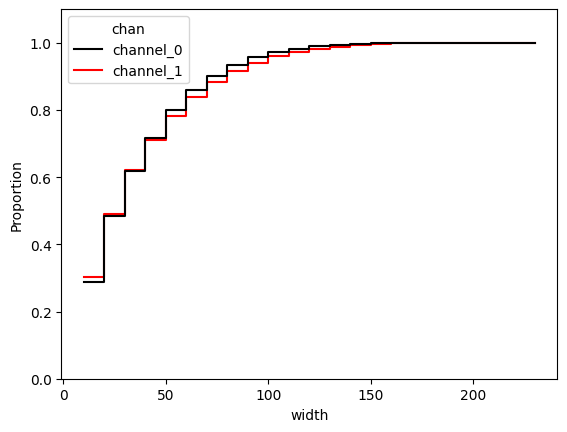

In [41]:
fig,ax = plt.subplots()
sns.histplot(data=df, x='width', hue='chan', cumulative=True, hue_order=('channel_0', 'channel_1'), palette=['black', 'red'],
            binwidth=10, fill=False, element = 'step', stat='proportion', common_norm=False, ax=ax)
ax.set_ylim([0,1.1])

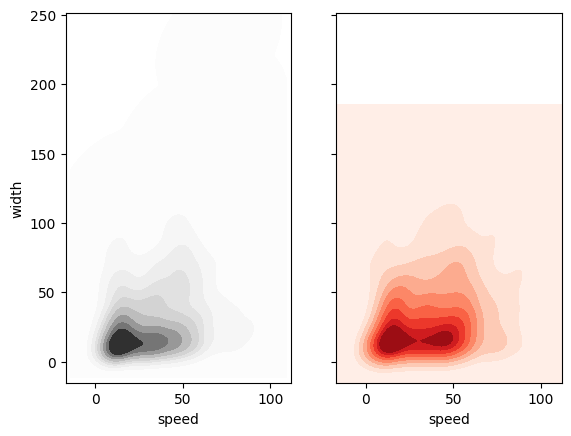

In [42]:
fig, ax = plt.subplots(1,2, sharex=True, sharey=True)

sns.kdeplot(
    data = df.loc[(df['chan']=='channel_0') * (df['day']==5),:],
    x = 'speed',
    y='width',
    ax=ax[0],
    cmap='Greys',
    fill=True,
    levels=10,
    thresh=0
)

sns.kdeplot(
    data = df.loc[(df['chan']=='channel_1') * (df['day']==5),:],
    x = 'speed',
    y='width',
    ax=ax[1],
    cmap='Reds',
    fill=True,
    levels=10,
    thresh=0
)

n_bins = 5
speed = df['speed']._values
speed_bins = np.quantile(speed[~np.isnan(speed)],np.linspace(0,1,num=n_bins+1))



# for a in ax:
#     a.set_xlim([0,80])
#     a.set_ylim([-5,175])
#     a.vlines(speed_bins[1:-1],-20,180,linestyle='--', color='k',alpha=.3)